In [1]:
!python -m pip install -q numpy pandas Pillow matplotlib seaborn scikit-learn torch torchvision tqdm


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [9]:
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/MyProject1')
PACKAGE_DIR = PROJECT_ROOT / 'stage5_package'
MANIFEST_DIR = PROJECT_ROOT / 'stage3_outputs_colab'
DRIVE_DATASET_ROOT = PROJECT_ROOT / 'DB'
LOCAL_RUNTIME_ROOT = Path('/content/MyProject1_runtime')
LOCAL_DATASET_ROOT = LOCAL_RUNTIME_ROOT / 'DB'
OUTPUT_ROOT = PACKAGE_DIR / 'experiment_outputs'
DEVICE = 'cuda' if __import__('torch').cuda.is_available() else 'cpu'
RANDOM_SEED = 42

EXPERIMENTS = [
    {
        'name': 'resnet18_baseline',
        'model_name': 'resnet18',
        'image_size': 160,
        'batch_size': 256,
        'num_epochs': 20,
        'learning_rate': 1e-4,
        'weight_decay': 1e-4,
        'num_workers': 2,
        'use_pretrained': True,
    },
    {
        'name': 'resnet34_deeper',
        'model_name': 'resnet34',
        'image_size': 160,
        'batch_size': 256,
        'num_epochs': 20,
        'learning_rate': 1e-4,
        'weight_decay': 1e-4,
        'num_workers': 2,
        'use_pretrained': True,
    },
    {
        'name': 'mobilenet_v3_small_fast',
        'model_name': 'mobilenet_v3_small',
        'image_size': 160,
        'batch_size': 256,
        'num_epochs': 20,
        'learning_rate': 1e-4,
        'weight_decay': 1e-4,
        'num_workers': 2,
        'use_pretrained': True,
    },
]

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT      =', PROJECT_ROOT)
print('PACKAGE_DIR       =', PACKAGE_DIR)
print('MANIFEST_DIR      =', MANIFEST_DIR)
print('DRIVE_DATASET_ROOT=', DRIVE_DATASET_ROOT)
print('LOCAL_DATASET_ROOT=', LOCAL_DATASET_ROOT)
print('OUTPUT_ROOT       =', OUTPUT_ROOT)
print('DEVICE            =', DEVICE)
print('EXPERIMENTS       =', len(EXPERIMENTS))


PROJECT_ROOT      = /content/drive/MyDrive/MyProject1
PACKAGE_DIR       = /content/drive/MyDrive/MyProject1/stage5_package
MANIFEST_DIR      = /content/drive/MyDrive/MyProject1/stage3_outputs_colab
DRIVE_DATASET_ROOT= /content/drive/MyDrive/MyProject1/DB
LOCAL_DATASET_ROOT= /content/MyProject1_runtime/DB
OUTPUT_ROOT       = /content/drive/MyDrive/MyProject1/stage5_package/experiment_outputs
DEVICE            = cuda
EXPERIMENTS       = 3


In [4]:
import shutil

assert PROJECT_ROOT.exists(), f'Project root not found: {PROJECT_ROOT}'
assert PACKAGE_DIR.exists(), f'Package folder not found: {PACKAGE_DIR}'
assert DRIVE_DATASET_ROOT.exists(), f'Dataset folder not found: {DRIVE_DATASET_ROOT}'
assert MANIFEST_DIR.exists(), f'Manifest folder not found: {MANIFEST_DIR}'

LOCAL_RUNTIME_ROOT.mkdir(parents=True, exist_ok=True)
if LOCAL_DATASET_ROOT.exists():
    shutil.rmtree(LOCAL_DATASET_ROOT)
shutil.copytree(DRIVE_DATASET_ROOT, LOCAL_DATASET_ROOT)

print('Dataset copied to local runtime:', LOCAL_DATASET_ROOT)


Dataset copied to local runtime: /content/MyProject1_runtime/DB


In [5]:
import json
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import (
    MobileNet_V3_Small_Weights,
    ResNet18_Weights,
    ResNet34_Weights,
    mobilenet_v3_small,
    resnet18,
    resnet34,
)
from tqdm.auto import tqdm


In [10]:
class SteelDefectDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row['resolved_image_path']).convert('RGB')
        target = int(row['target'])
        if self.transform is not None:
            image = self.transform(image)
        return image, target


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def rebuild_image_path(image_path, source_folder, dataset_root):
    image_name = Path(image_path).name
    return str(dataset_root / 'images' / 'images' / source_folder / image_name)


def resolve_image_path(image_path, source_folder, dataset_root):
    raw_path = Path(image_path)
    if raw_path.exists():
        return str(raw_path)
    return rebuild_image_path(image_path, source_folder, dataset_root)


def load_manifest(csv_path, dataset_root):
    dataframe = pd.read_csv(csv_path)
    dataframe['resolved_image_path'] = dataframe.apply(
        lambda row: resolve_image_path(row['image_path'], row['source_folder'], dataset_root),
        axis=1,
    )
    return dataframe


def build_target_mapping(train_df):
    classes = train_df[['class_id', 'class_name']].drop_duplicates().sort_values('class_id').reset_index(drop=True)
    class_id_to_target = {int(row.class_id): idx for idx, row in classes.iterrows()}
    target_to_class_name = {idx: row.class_name for idx, row in classes.iterrows()}
    target_to_class_id = {idx: int(row.class_id) for idx, row in classes.iterrows()}
    return class_id_to_target, target_to_class_name, target_to_class_id


def prepare_targets(dataframe, class_id_to_target):
    prepared = dataframe.copy()
    prepared['target'] = prepared['class_id'].map(class_id_to_target)
    return prepared


def validate_manifest_paths(dataframe, split_name):
    missing_paths = [path for path in dataframe['resolved_image_path'] if not Path(path).exists()]
    if missing_paths:
        preview = '\n'.join(f'  - {path}' for path in missing_paths[:10])
        raise FileNotFoundError(f'{split_name} has {len(missing_paths)} missing image files.\n{preview}')


def build_transforms(image_size):
    train_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=5),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    eval_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    return train_transform, eval_transform


def create_dataloaders(train_df, val_df, test_df, image_size, batch_size, num_workers, device):
    train_transform, eval_transform = build_transforms(image_size)
    pin_memory = str(device).startswith('cuda')
    train_dataset = SteelDefectDataset(train_df, transform=train_transform)
    val_dataset = SteelDefectDataset(val_df, transform=eval_transform)
    test_dataset = SteelDefectDataset(test_df, transform=eval_transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin_memory)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
    return train_loader, val_loader, test_loader


def build_model(model_name, num_classes, pretrained=True):
    if model_name == 'resnet18':
        weights = ResNet18_Weights.DEFAULT if pretrained else None
        model = resnet18(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        return model
    if model_name == 'resnet34':
        weights = ResNet34_Weights.DEFAULT if pretrained else None
        model = resnet34(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        return model
    if model_name == 'mobilenet_v3_small':
        weights = MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
        model = mobilenet_v3_small(weights=weights)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        return model
    raise ValueError(f'Unsupported model: {model_name}')


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_targets = []
    all_preds = []
    for images, targets in loader:
        images = images.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        preds = outputs.argmax(dim=1)
        running_loss += loss.item() * images.size(0)
        all_targets.extend(targets.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())
    return running_loss / len(loader.dataset), accuracy_score(all_targets, all_preds)


def evaluate_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_targets = []
    all_preds = []
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)
            outputs = model(images)
            loss = criterion(outputs, targets)
            preds = outputs.argmax(dim=1)
            running_loss += loss.item() * images.size(0)
            all_targets.extend(targets.detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())
    return running_loss / len(loader.dataset), accuracy_score(all_targets, all_preds), all_targets, all_preds


def save_json(payload, output_path):
    with open(output_path, 'w', encoding='utf-8') as fp:
        json.dump(payload, fp, ensure_ascii=False, indent=2)


def plot_history(history_df, output_path, title_suffix=''):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history_df['epoch'], history_df['train_loss'], label='train_loss')
    axes[0].plot(history_df['epoch'], history_df['val_loss'], label='val_loss')
    axes[0].set_title(f'Loss {title_suffix}'.strip())
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[1].plot(history_df['epoch'], history_df['train_accuracy'], label='train_accuracy')
    axes[1].plot(history_df['epoch'], history_df['val_accuracy'], label='val_accuracy')
    axes[1].set_title(f'Accuracy {title_suffix}'.strip())
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    plt.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close(fig)


def plot_confusion(y_true, y_pred, class_names, output_path, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close(fig)


def build_test_metrics(y_true, y_pred, class_names):
    report = classification_report(y_true, y_pred, labels=list(range(len(class_names))), target_names=class_names, output_dict=True, zero_division=0)
    return {
        'test_accuracy': float(accuracy_score(y_true, y_pred)),
        'macro_avg_f1': float(report['macro avg']['f1-score']),
        'weighted_avg_f1': float(report['weighted avg']['f1-score']),
    }


def fit_single_experiment(config, dataset_root, manifest_dir, output_root, device, random_seed):
    set_seed(random_seed)
    experiment_dir = output_root / config['name']
    models_dir = experiment_dir / 'models'
    reports_dir = experiment_dir / 'reports'
    plots_dir = experiment_dir / 'plots'
    for directory in [experiment_dir, models_dir, reports_dir, plots_dir]:
        directory.mkdir(parents=True, exist_ok=True)

    train_df = load_manifest(manifest_dir / 'train_manifest.csv', dataset_root)
    val_df = load_manifest(manifest_dir / 'val_manifest.csv', dataset_root)
    test_df = load_manifest(manifest_dir / 'test_manifest.csv', dataset_root)
    validate_manifest_paths(train_df, 'train')
    validate_manifest_paths(val_df, 'val')
    validate_manifest_paths(test_df, 'test')

    class_id_to_target, target_to_class_name, _ = build_target_mapping(train_df)
    train_df = prepare_targets(train_df, class_id_to_target)
    val_df = prepare_targets(val_df, class_id_to_target)
    test_df = prepare_targets(test_df, class_id_to_target)
    class_names = [target_to_class_name[idx] for idx in sorted(target_to_class_name.keys())]

    train_loader, val_loader, test_loader = create_dataloaders(
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        image_size=config['image_size'],
        batch_size=config['batch_size'],
        num_workers=config['num_workers'],
        device=device,
    )

    model = build_model(config['model_name'], num_classes=len(class_names), pretrained=config['use_pretrained']).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=config['learning_rate'], weight_decay=config['weight_decay'])
    trainable_parameters = count_parameters(model)

    history_rows = []
    best_state_dict = None
    best_val_accuracy = -1.0

    total_batches = config['num_epochs'] * (len(train_loader) + len(val_loader)) + len(test_loader)
    with tqdm(total=total_batches, desc=config['name'], unit='batch') as progress_bar:
        for epoch in range(1, config['num_epochs'] + 1):
            epoch_started = time.time()
            train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device)
            progress_bar.update(len(train_loader))
            val_loss, val_accuracy, _, _ = evaluate_model(model, val_loader, criterion, device)
            progress_bar.update(len(val_loader))
            history_rows.append({
                'epoch': epoch,
                'train_loss': train_loss,
                'train_accuracy': train_accuracy,
                'val_loss': val_loss,
                'val_accuracy': val_accuracy,
                'epoch_time_sec': time.time() - epoch_started,
            })
            progress_bar.set_postfix(epoch=f'{epoch}/{config["num_epochs"]}', train_acc=f'{train_accuracy:.3f}', val_acc=f'{val_accuracy:.3f}')
            print(f"Epoch {epoch:02d}/{config['num_epochs']} [{config['name']}]: train_acc={train_accuracy:.4f}, val_acc={val_accuracy:.4f}")
            if val_accuracy > best_val_accuracy:
                best_val_accuracy = val_accuracy
                best_state_dict = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

        model.load_state_dict(best_state_dict)
        test_loss, test_accuracy, y_true, y_pred = evaluate_model(model, test_loader, criterion, device)
        progress_bar.update(len(test_loader))

    history_df = pd.DataFrame(history_rows)
    metrics = build_test_metrics(y_true, y_pred, class_names)
    metrics['best_val_accuracy'] = float(best_val_accuracy)
    metrics['test_loss'] = float(test_loss)
    metrics['trainable_parameters'] = int(trainable_parameters)
    metrics['model_name'] = config['model_name']

    model_path = models_dir / f"{config['model_name']}_best_model.pth"
    history_path = reports_dir / 'history.csv'
    metrics_path = reports_dir / 'metrics.json'
    summary_path = reports_dir / 'summary.json'
    history_plot_path = plots_dir / 'training_history.png'
    confusion_plot_path = plots_dir / 'confusion_matrix.png'

    torch.save(model.state_dict(), model_path)
    history_df.to_csv(history_path, index=False)
    save_json(metrics, metrics_path)
    plot_history(history_df, history_plot_path, title_suffix=config['name'])
    plot_confusion(y_true, y_pred, class_names, confusion_plot_path, title=f"Confusion Matrix: {config['name']}")

    summary = {
        'experiment_name': config['name'],
        'model_name': config['model_name'],
        'image_size': config['image_size'],
        'batch_size': config['batch_size'],
        'num_epochs': config['num_epochs'],
        'learning_rate': config['learning_rate'],
        'weight_decay': config['weight_decay'],
        'num_workers': config['num_workers'],
        'use_pretrained': config['use_pretrained'],
        'device': device,
        'trainable_parameters': int(trainable_parameters),
        'metrics': metrics,
        'artifacts': {
            'model_path': str(model_path),
            'history_path': str(history_path),
            'metrics_path': str(metrics_path),
            'history_plot_path': str(history_plot_path),
            'confusion_plot_path': str(confusion_plot_path),
        },
    }
    save_json(summary, summary_path)

    return {
        'experiment_name': config['name'],
        'model_name': config['model_name'],
        'image_size': config['image_size'],
        'batch_size': config['batch_size'],
        'num_epochs': config['num_epochs'],
        'best_val_accuracy': float(best_val_accuracy),
        'test_accuracy': float(metrics['test_accuracy']),
        'macro_avg_f1': float(metrics['macro_avg_f1']),
        'weighted_avg_f1': float(metrics['weighted_avg_f1']),
        'trainable_parameters': int(trainable_parameters),
        'artifacts_dir': str(experiment_dir),
    }


def run_experiments(experiments, dataset_root, manifest_dir, output_root, device, random_seed):
    results = []
    for experiment in experiments:
        print(f"\n=== Running experiment: {experiment['name']} ===")
        result = fit_single_experiment(
            config=experiment,
            dataset_root=dataset_root,
            manifest_dir=manifest_dir,
            output_root=output_root,
            device=device,
            random_seed=random_seed,
        )
        results.append(result)
    comparison_df = pd.DataFrame(results)
    comparison_df['parameters_millions'] = comparison_df['trainable_parameters'] / 1_000_000
    comparison_df['accuracy_per_million_params'] = comparison_df['test_accuracy'] / comparison_df['parameters_millions']
    comparison_df = comparison_df.sort_values(['test_accuracy', 'macro_avg_f1'], ascending=False).reset_index(drop=True)
    comparison_df.to_csv(output_root / 'comparison.csv', index=False)
    return comparison_df


def plot_comparison_chart(comparison_df, output_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(comparison_df['experiment_name'], comparison_df['test_accuracy'])
    axes[0].set_title('Test Accuracy by Experiment')
    axes[0].tick_params(axis='x', rotation=20)
    axes[1].bar(comparison_df['experiment_name'], comparison_df['accuracy_per_million_params'])
    axes[1].set_title('Accuracy per Million Parameters')
    axes[1].tick_params(axis='x', rotation=20)
    plt.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close(fig)


In [11]:
comparison_df = run_experiments(
    experiments=EXPERIMENTS,
    dataset_root=LOCAL_DATASET_ROOT,
    manifest_dir=MANIFEST_DIR,
    output_root=OUTPUT_ROOT,
    device=DEVICE,
    random_seed=RANDOM_SEED,
)

plot_comparison_chart(comparison_df, OUTPUT_ROOT / 'comparison.png')
comparison_df



=== Running experiment: resnet18_baseline ===


resnet18_baseline:   0%|          | 0/142 [00:00<?, ?batch/s]

Epoch 01/20 [resnet18_baseline]: train_acc=0.2151, val_acc=0.2096
Epoch 02/20 [resnet18_baseline]: train_acc=0.6139, val_acc=0.3493
Epoch 03/20 [resnet18_baseline]: train_acc=0.7463, val_acc=0.5551
Epoch 04/20 [resnet18_baseline]: train_acc=0.7920, val_acc=0.6434
Epoch 05/20 [resnet18_baseline]: train_acc=0.8479, val_acc=0.6875
Epoch 06/20 [resnet18_baseline]: train_acc=0.8936, val_acc=0.7243
Epoch 07/20 [resnet18_baseline]: train_acc=0.9157, val_acc=0.7463
Epoch 08/20 [resnet18_baseline]: train_acc=0.9370, val_acc=0.7868
Epoch 09/20 [resnet18_baseline]: train_acc=0.9472, val_acc=0.8125
Epoch 10/20 [resnet18_baseline]: train_acc=0.9543, val_acc=0.8309
Epoch 11/20 [resnet18_baseline]: train_acc=0.9685, val_acc=0.8566
Epoch 12/20 [resnet18_baseline]: train_acc=0.9716, val_acc=0.8603
Epoch 13/20 [resnet18_baseline]: train_acc=0.9819, val_acc=0.8603
Epoch 14/20 [resnet18_baseline]: train_acc=0.9858, val_acc=0.8676
Epoch 15/20 [resnet18_baseline]: train_acc=0.9850, val_acc=0.8713
Epoch 16/2

resnet34_deeper:   0%|          | 0/142 [00:00<?, ?batch/s]

Epoch 01/20 [resnet34_deeper]: train_acc=0.1686, val_acc=0.1250
Epoch 02/20 [resnet34_deeper]: train_acc=0.5626, val_acc=0.2757
Epoch 03/20 [resnet34_deeper]: train_acc=0.7557, val_acc=0.5110
Epoch 04/20 [resnet34_deeper]: train_acc=0.8329, val_acc=0.6728
Epoch 05/20 [resnet34_deeper]: train_acc=0.8810, val_acc=0.7721
Epoch 06/20 [resnet34_deeper]: train_acc=0.9094, val_acc=0.8272
Epoch 07/20 [resnet34_deeper]: train_acc=0.9377, val_acc=0.8529
Epoch 08/20 [resnet34_deeper]: train_acc=0.9551, val_acc=0.8493
Epoch 09/20 [resnet34_deeper]: train_acc=0.9685, val_acc=0.8382
Epoch 10/20 [resnet34_deeper]: train_acc=0.9771, val_acc=0.8676
Epoch 11/20 [resnet34_deeper]: train_acc=0.9811, val_acc=0.8824
Epoch 12/20 [resnet34_deeper]: train_acc=0.9811, val_acc=0.8493
Epoch 13/20 [resnet34_deeper]: train_acc=0.9866, val_acc=0.8493
Epoch 14/20 [resnet34_deeper]: train_acc=0.9905, val_acc=0.8640
Epoch 15/20 [resnet34_deeper]: train_acc=0.9961, val_acc=0.8676
Epoch 16/20 [resnet34_deeper]: train_acc

mobilenet_v3_small_fast:   0%|          | 0/142 [00:00<?, ?batch/s]

Epoch 01/20 [mobilenet_v3_small_fast]: train_acc=0.1545, val_acc=0.0404
Epoch 02/20 [mobilenet_v3_small_fast]: train_acc=0.3491, val_acc=0.0331
Epoch 03/20 [mobilenet_v3_small_fast]: train_acc=0.3727, val_acc=0.0515
Epoch 04/20 [mobilenet_v3_small_fast]: train_acc=0.3885, val_acc=0.0919
Epoch 05/20 [mobilenet_v3_small_fast]: train_acc=0.4027, val_acc=0.1801
Epoch 06/20 [mobilenet_v3_small_fast]: train_acc=0.4405, val_acc=0.2096
Epoch 07/20 [mobilenet_v3_small_fast]: train_acc=0.4949, val_acc=0.2537
Epoch 08/20 [mobilenet_v3_small_fast]: train_acc=0.5359, val_acc=0.2904
Epoch 09/20 [mobilenet_v3_small_fast]: train_acc=0.6060, val_acc=0.3162
Epoch 10/20 [mobilenet_v3_small_fast]: train_acc=0.6178, val_acc=0.3640
Epoch 11/20 [mobilenet_v3_small_fast]: train_acc=0.6667, val_acc=0.3750
Epoch 12/20 [mobilenet_v3_small_fast]: train_acc=0.6903, val_acc=0.4118
Epoch 13/20 [mobilenet_v3_small_fast]: train_acc=0.7179, val_acc=0.4191
Epoch 14/20 [mobilenet_v3_small_fast]: train_acc=0.7242, val_acc

,experiment_name,model_name,image_size,batch_size,num_epochs,best_val_accuracy,test_accuracy,macro_avg_f1,weighted_avg_f1,trainable_parameters,artifacts_dir,parameters_millions,accuracy_per_million_params
0,resnet18_baseline,resnet18,160,256,20,0.882353,0.897436,0.820071,0.894555,11181642,/content/drive/MyDrive/MyProject1/stage5_packa...,11.181642,0.080260
1,resnet34_deeper,resnet34,160,256,20,0.882353,0.857143,0.731542,0.852522,21289802,/content/drive/MyDrive/MyProject1/stage5_packa...,21.289802,0.040261
2,mobilenet_v3_small_fast,mobilenet_v3_small,160,256,20,0.518382,0.490842,0.266949,0.431497,1528106,/content/drive/MyDrive/MyProject1/stage5_packa...,1.528106,0.321210


,experiment_name,model_name,image_size,batch_size,num_epochs,best_val_accuracy,test_accuracy,macro_avg_f1,weighted_avg_f1,trainable_parameters,artifacts_dir,parameters_millions,accuracy_per_million_params
0,resnet18_baseline,resnet18,160,256,20,0.882353,0.897436,0.820071,0.894555,11181642,/content/drive/MyDrive/MyProject1/stage5_packa...,11.181642,0.080260
1,resnet34_deeper,resnet34,160,256,20,0.882353,0.857143,0.731542,0.852522,21289802,/content/drive/MyDrive/MyProject1/stage5_packa...,21.289802,0.040261
2,mobilenet_v3_small_fast,mobilenet_v3_small,160,256,20,0.518382,0.490842,0.266949,0.431497,1528106,/content/drive/MyDrive/MyProject1/stage5_packa...,1.528106,0.321210


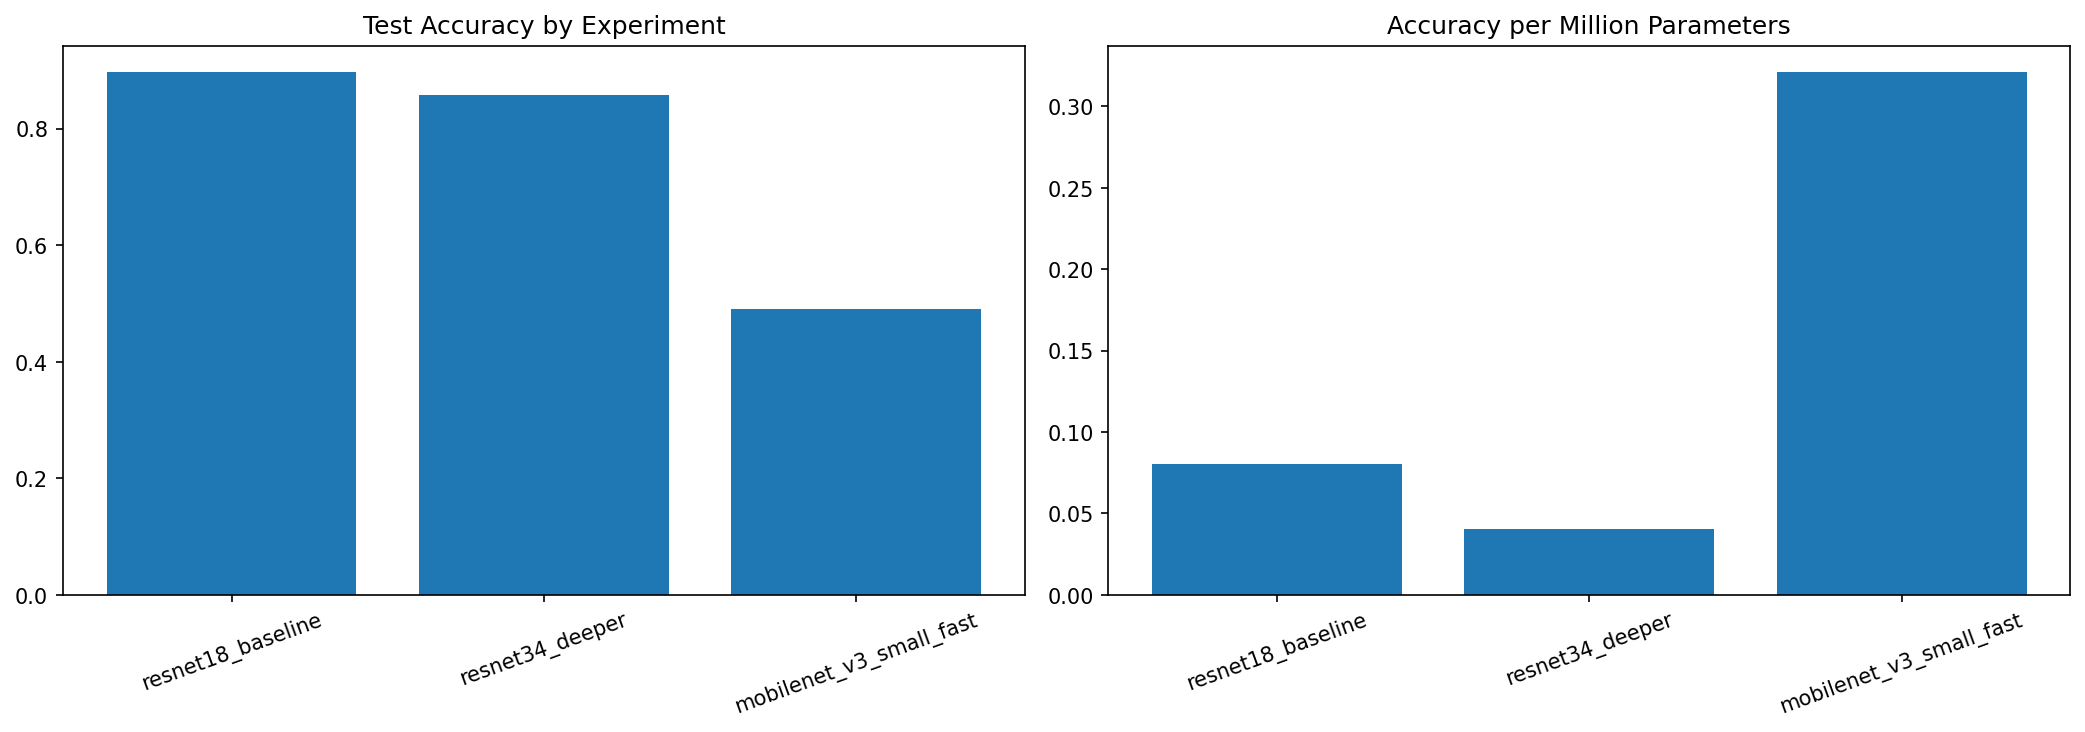

Best by accuracy:
experiment_name        resnet18_baseline
model_name                      resnet18
test_accuracy                   0.897436
macro_avg_f1                    0.820071
parameters_millions            11.181642
Name: 0, dtype: object

Best by accuracy/params:
experiment_name                mobilenet_v3_small_fast
model_name                          mobilenet_v3_small
test_accuracy                                 0.490842
macro_avg_f1                                  0.266949
parameters_millions                           1.528106
accuracy_per_million_params                    0.32121
Name: 2, dtype: object


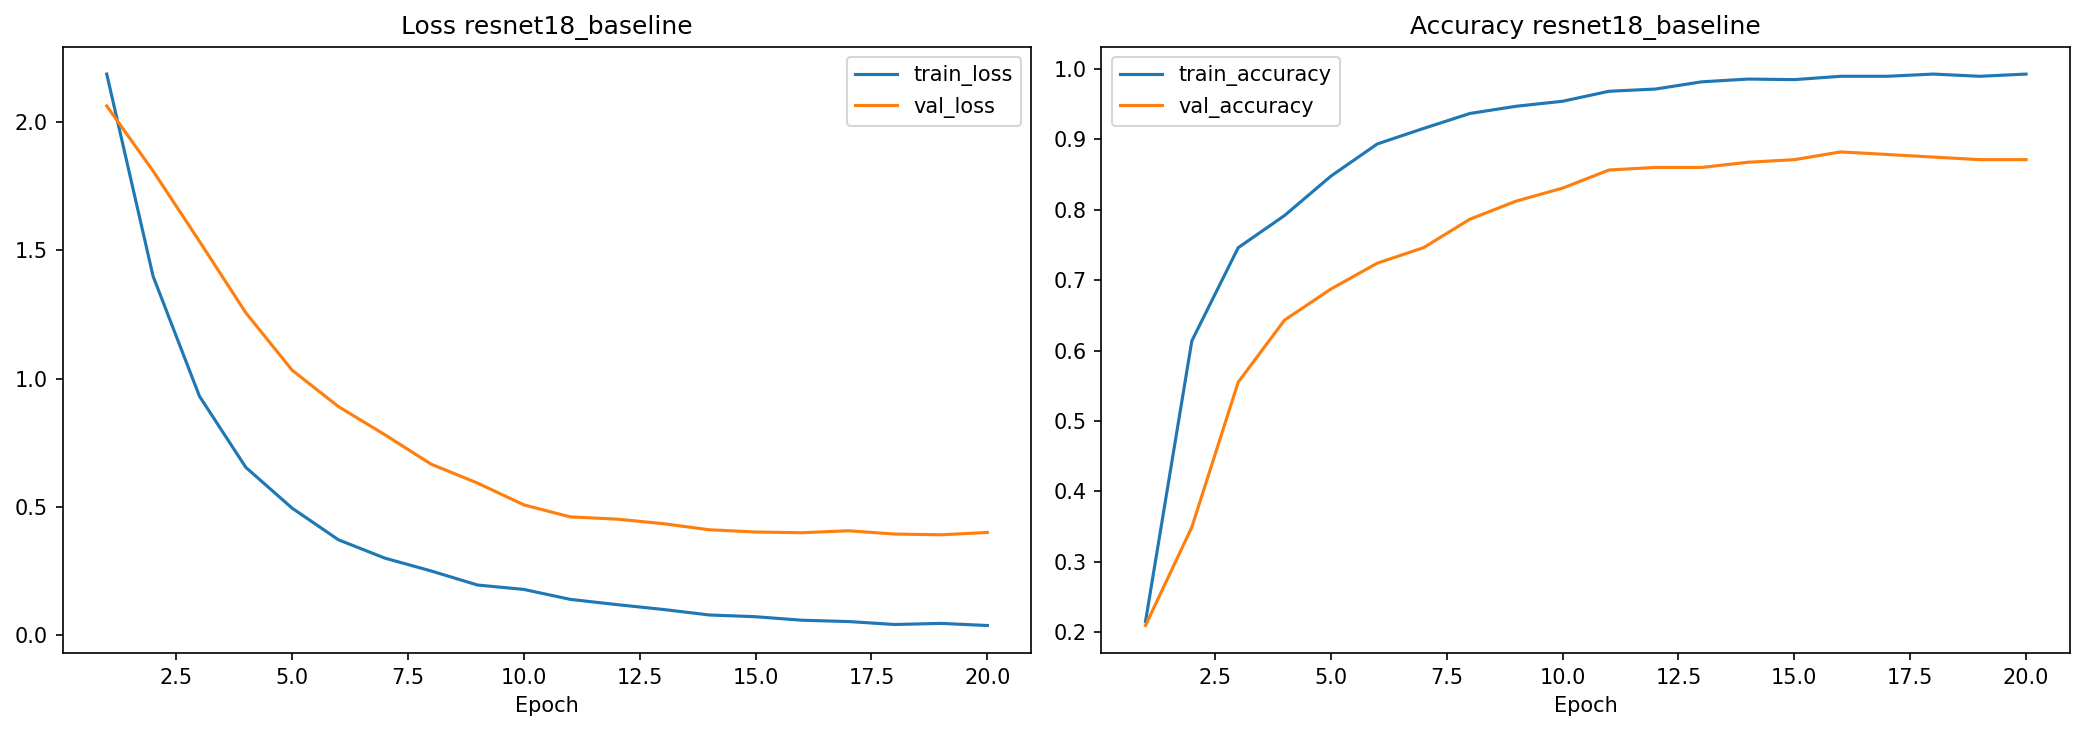

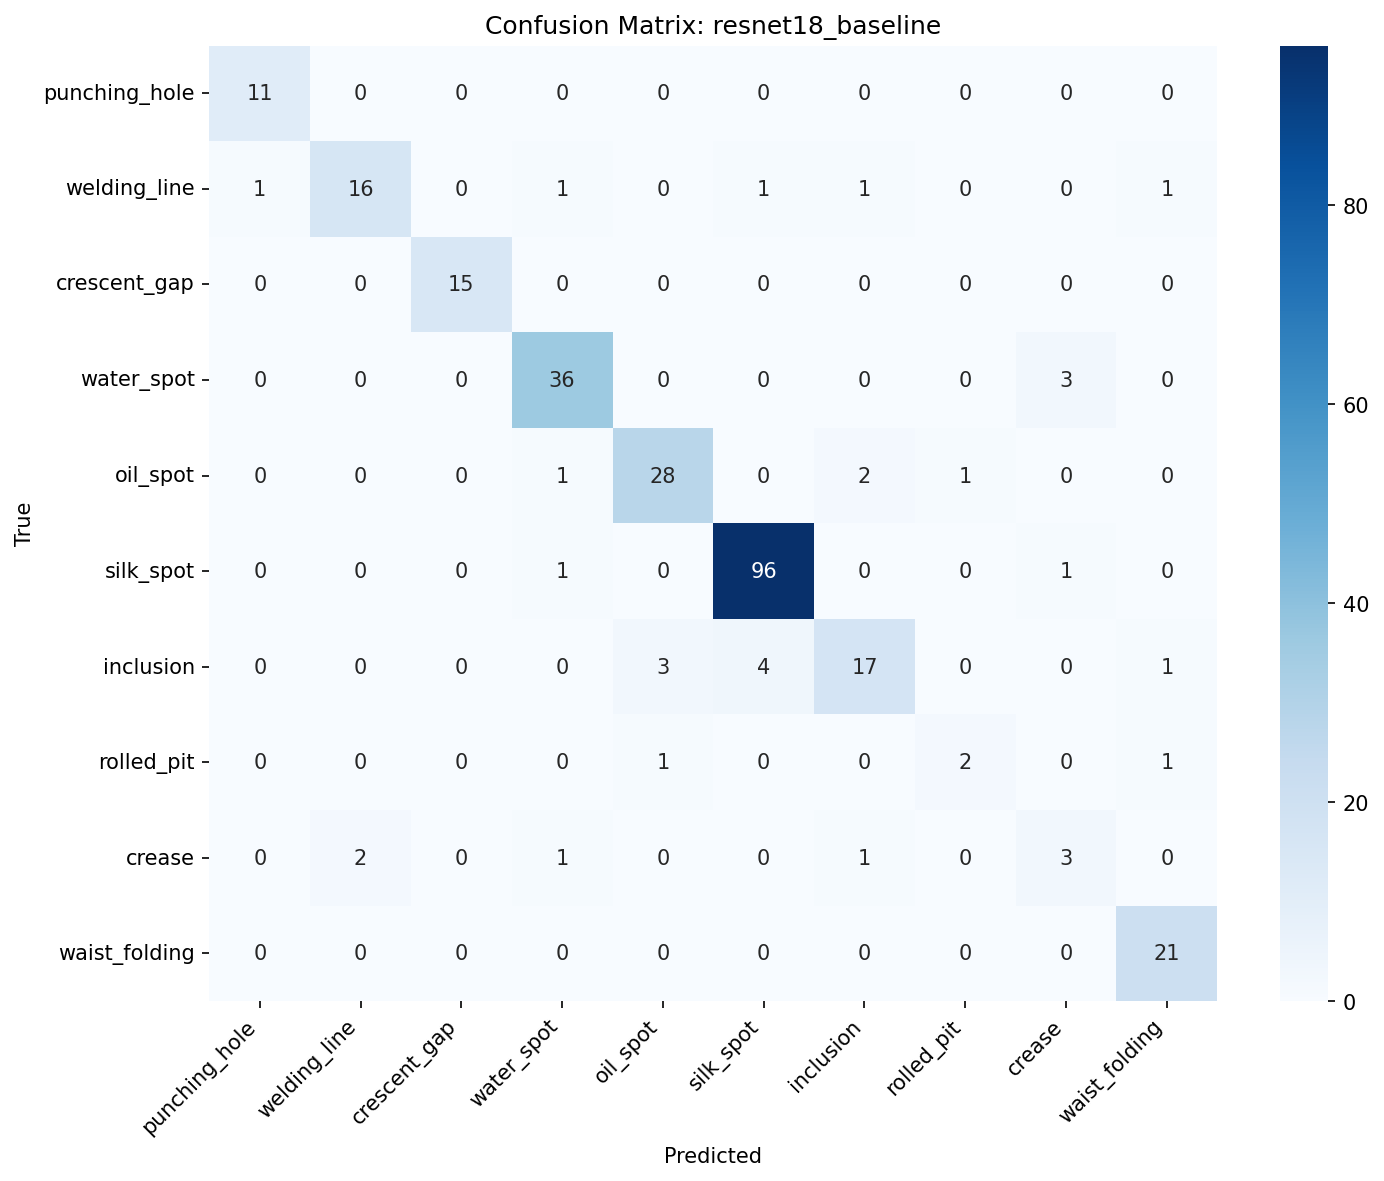

In [12]:
from IPython.display import Image as IPyImage, display

display(comparison_df)
display(IPyImage(filename=str(OUTPUT_ROOT / 'comparison.png')))

best_accuracy_row = comparison_df.sort_values(['test_accuracy', 'macro_avg_f1'], ascending=False).iloc[0]
best_efficiency_row = comparison_df.sort_values(['accuracy_per_million_params', 'test_accuracy'], ascending=False).iloc[0]

print('Best by accuracy:')
print(best_accuracy_row[['experiment_name', 'model_name', 'test_accuracy', 'macro_avg_f1', 'parameters_millions']])
print('\nBest by accuracy/params:')
print(best_efficiency_row[['experiment_name', 'model_name', 'test_accuracy', 'macro_avg_f1', 'parameters_millions', 'accuracy_per_million_params']])

best_experiment_dir = Path(best_accuracy_row['artifacts_dir'])
display(IPyImage(filename=str(best_experiment_dir / 'plots' / 'training_history.png')))
display(IPyImage(filename=str(best_experiment_dir / 'plots' / 'confusion_matrix.png')))
